In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple


In [2]:
from model_prototype_nb1_utils import Particle,compute_alignment,compute_gradient



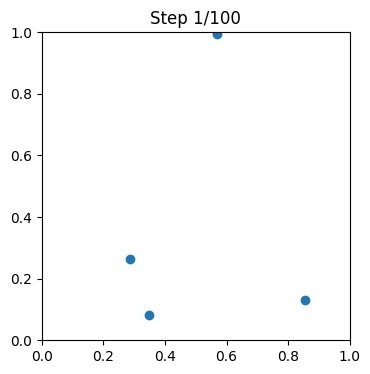

In [3]:
def seed_particles(num_particles=4, L=1.0, rng=None):
    """Sample an initial particle set inside a periodic box."""
    rng = rng or np.random.default_rng()
    return [
        Particle(
            i,
            float(rng.random() * L),
            float(rng.random() * L),
            float(rng.random() * 2 * np.pi),
        )
        for i in range(num_particles)
    ]


def advance_system(particles, Radius, L):
    """Perform one Vicsek-style update and return Nx2 positions array."""
    for i, p in enumerate(particles):
        alignment = compute_alignment(i, particles, Radius, L)
        gradx, grady = 0.0, 0.0
        p.update_theta(alignment, gradx, grady)

    for p in particles:
        p.move(L)

    return np.array([[p.x, p.y] for p in particles])


steps = 100
L = 1.0
Radius = 0.1
particles = seed_particles(num_particles=4, L=L)

plt.ion()
fig, ax = plt.subplots(figsize=(4, 4))
ax.set_xlim(0, L)
ax.set_ylim(0, L)
ax.set_aspect("equal")
scat = ax.scatter([], [])

for step in range(steps):
    positions = advance_system(particles, Radius, L)
    scat.set_offsets(positions)
    ax.set_title(f"Step {step + 1}/{steps}")
    plt.pause(0.01)

plt.ioff()


In [7]:
import imageio.v2 as imageio
from pathlib import Path

# re-run a simulation while capturing every frame
particles = []
steps = 1000
L = 10
Radius = 0.1
fps = 24

for i in range(4):
    x = np.random.random()
    y = np.random.random()
    theta = 2 * np.pi * np.random.random()
    particles.append(Particle(i, x, y, theta))

fig, ax = plt.subplots(figsize=(4, 4))
ax.set_xlim(0, L)
ax.set_ylim(0, L)
ax.set_aspect("equal")
scat = ax.scatter([p.x for p in particles], [p.y for p in particles])
frames = []

for step in range(steps):
    for i, p in enumerate(particles):
        alignment = compute_alignment(i, particles, Radius, L)
        gradx, grady = 0.0, 0.0  # no chemotaxis yet
        p.update_theta(alignment, gradx, grady)

    for p in particles:
        p.move(L)

    scat.set_offsets(np.array([[p.x, p.y] for p in particles]))
    ax.set_title(f"Step {step+1}/{steps}")
    fig.canvas.draw()
    rgba = np.asarray(fig.canvas.buffer_rgba())
    frame = rgba[:, :, :3].copy()
    frames.append(frame)

output_path = Path("output/particle_simulation.mp4")
output_path.parent.mkdir(parents=True, exist_ok=True)
imageio.mimsave(output_path, frames, fps=fps, codec="libx264")
print(f"Saved movie to {output_path.resolve()}")


Saved movie to /work/vicsek_model/output/particle_simulation.mp4


In [5]:
import imageio.v2 as imageio
from pathlib import Path

fps = 30
movie_steps = 100
rng = np.random.default_rng(123)
particles = seed_particles(num_particles=4, L=L, rng=rng)

fig, ax = plt.subplots(figsize=(4, 4))
ax.set_xlim(0, L)
ax.set_ylim(0, L)
ax.set_aspect("equal")
scat = ax.scatter([], [])
frames = []

for step in range(movie_steps):
    positions = advance_system(particles, Radius, L)
    scat.set_offsets(positions)
    ax.set_title(f"Movie Step {step + 1}/{movie_steps}")
    fig.canvas.draw()
    rgba = np.asarray(fig.canvas.buffer_rgba())
    frames.append(rgba[:, :, :3].copy())

plt.close(fig)

output_path = Path("output/particle_simulation.mp4")
output_path.parent.mkdir(parents=True, exist_ok=True)
imageio.mimsave(output_path, frames, fps=fps, codec="libx264")
print(f"Saved movie to {output_path.resolve()}")


Saved movie to /work/vicsek_model/output/particle_simulation.mp4
